# 12 · E3c: what kind of change is the drift?

**Where E3 and E3b left off (68 Atanas et al. recordings).**
* A program fitted on the past goes stale in about 70 % of recordings (Notebook 10).
* No compact activity-driven meta-program absorbs the change (Notebook 10).
* The drift is **not** concentrated in the neurons whose behavioral encoding changed (E3b-A: p = 0.85).
* It is **not** slow behavioral state either (E3b-B: p = 0.63).

So the drift is diffuse. This notebook asks **what form it takes**. At each forecast window, the program fitted on the past is updated in one restricted way on the recent past (the first half of the window), then scored on the window's second half. Scoring out of sample means a richer update helps only if the change really has that form.

| family | what changes | reading if it beats `bias` |
|---|---|---|
| `bias` | each neuron's drive (Notebook 10's "refit") | (the reference) |
| `renorm`, `rescale` | the **measurement**: the traces' mean and scale (bleaching, focus) | a recording artefact |
| `gain_global`, `gain_neuron` | the gain of recurrent input, globally or per neuron | neuromodulatory gain control |
| `lowrank1`, `lowrank2` | a rank-1 or rank-2 change of the couplings | a few global modes reconfigure the network |
| `dense` | an unstructured change of all couplings | rewiring with no simple structure |

Two further questions:
* **Dimensionality.** Do all neurons' drives move together, i.e. along one direction across the recording? That would point to one slow hidden variable: a neuromodulator, unrecorded neurons (about half of the 302 are not imaged), or the microscope.
* **Measurement.** Is the drift larger in recordings whose raw fluorescence fades more (`trace_array_original`)?

**What the synthetic checks showed while building this.**
* Multiplicative measurement drift (even a 60 % bleach) produces *no* forecast drift: after z-scoring, a near-linear program is scale-equivariant.
* Additive offset drift does produce forecast drift. The `bias` family absorbs it, just as it absorbs a change of drives.

So the dynamics alone cannot tell an observation offset from a drive change. §5 answers the measurement question from the raw traces instead.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, time, datetime, numpy as np, matplotlib.pyplot as plt
from scipy.stats import wilcoxon, spearmanr
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 11, 0), \
    f"Notebook 12 needs closurebench >= 0.11.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import drift as DR, drift_kinds as DK
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {"smoke": dict(N_NULL=1, MAX_FILES=1), "laptop": dict(N_NULL=2, MAX_FILES=None), "full": dict(N_NULL=3, MAX_FILES=None)}[MODE]
globals().update(CONF)
N_WINDOWS, GAP_FLOOR = 8, 0.005
STRUCT = ("gain_global", "gain_neuron", "lowrank1", "lowrank2", "dense")
MEASF = ("renorm", "rescale")
TAG = "" if MODE == "full" else f"_{MODE}"
files = sorted(glob.glob(os.path.join(RESULTS, "spontaneous", "*.json")))[:MAX_FILES]
CK = os.path.join(RESULTS, "e3c_ck", MODE); os.makedirs(CK, exist_ok=True)
print(f"{len(files)} recordings; {N_NULL} stationary surrogates + 1 drive-drift + 1 measurement-drift surrogate each; checkpoints in {CK}")

68 recordings; 2 stationary surrogates + 1 drive-drift + 1 measurement-drift surrogate each; checkpoints in /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/e3c_ck/laptop


### Pre-registration (before §1)

Recorded in `results/E3c_preregistration*.json`.

**Drift-detected recordings** are those whose `bias` gap (refit − frozen) is at least the larger of 0.005 and the largest gap among the recording's stationary surrogates, as in Notebooks 10–11.

For a family F, its **advantage** is score_F − score_bias. Its **excess** is the real advantage minus the mean advantage on the recording's stationary surrogates, which removes what extra parameters gain by chance.

* **R1 · structure.** For each structural family, a one-sided Wilcoxon test checks whether the excess is > 0 across drift-detected recordings, with Holm correction over the 5 families.
  * STRUCTURE = at least one family passes.
  * The test is **valid** only if the same procedure flags no family on the drive-drift surrogates. Their drift is drives only, so no structure should be found.
* **R1m · measurement families.** The same test for `renorm` and `rescale`, with Holm correction over 2.
* **R2 · low-dimensional drives.** The drives are re-estimated in each of the 8 windows under one program; PC1 share is the share of their across-window variance on the first principal component.
  * LOW_DIM: PC1 share (real) − mean PC1 share (stationary surrogates) > 0, one-sided Wilcoxon p < 0.05, over drift-detected recordings.
* **R3 · measurement trend.** Spearman correlations across all recordings between the drift gap and the fading of the raw signal: the last/first-window ratio of the amplitude (sd) and of the mean.
  * MEAS_TREND = either correlation is negative with Holm-corrected p < 0.05 (more fading, more drift).

In [3]:
prereg = os.path.join(RESULTS, f"E3c_preregistration{TAG}.json")
plan = {"experiment": "E3c what kind of change is the drift", "mode": MODE,
        "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "config": {**CONF, "N_WINDOWS": N_WINDOWS, "GAP_FLOOR": GAP_FLOOR, "families": list(DK.FAMILIES)},
        "detected": "gap_bias >= max(GAP_FLOOR, max stationary-surrogate gap)",
        "R1": "excess_F = (score_F - score_bias)_real - mean over stationary surrogates; one-sided Wilcoxon > 0 over detected; Holm over STRUCT; valid only if no family flagged on drive-drift surrogates",
        "R1m": "same for renorm, rescale; Holm over 2",
        "R2": "pc1_real - mean pc1_null > 0, one-sided Wilcoxon p < 0.05 over detected",
        "R3": "Spearman(gap, sd_ratio) or Spearman(gap, mean_ratio) negative, Holm over 2, p < 0.05"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E3c_preregistration_laptop.json


## 1 · Per-recording analysis (checkpointed)

Each recording is analysed as it stands, and so are its surrogates: stationary ones, one with drifting drives, and one with drifting measurement. This takes about a minute per recording on a laptop, and each recording is saved as soon as it is done.

In [4]:
def run(Y, S, U):
    r = DK.family_scores(Y, S, U, n_windows=N_WINDOWS)
    r["pc1"] = DK.bias_trajectory(Y, S, U, n_windows=N_WINDOWS)[1]
    return r

rec = {}
for f in files:
    name = os.path.basename(f).replace(".json", "")[-13:]
    ck = os.path.join(CK, name + ".json")
    if os.path.exists(ck):
        rec[name] = json.load(open(ck)); continue
    t0 = time.time()
    R = DR.load_atanas(f); X, U = R["X"], R["U"]
    S = ~np.eye(X.shape[1], dtype=bool)
    out = {"N": int(X.shape[1]), "real": run(X, S, U), "trend": DK.signal_trend(f)}
    out["null"] = [run(Y, S, U) for Y in (DR.surrogate(X, S, U, seed=100 + s) for s in range(N_NULL)) if Y is not None]
    Yb = DR.surrogate(X, S, U, seed=200, drift_frac=0.07)
    out["drive_drift"] = run(Yb, S, U) if Yb is not None else None
    Ym = DK.measurement_surrogate(X, S, U, seed=300)
    out["meas_drift"] = run(Ym, S, U) if Ym is not None else None
    json.dump(out, open(ck, "w"), default=float); rec[name] = out
    r = out["real"]
    print(f"{name}: gap {r['gap']:+.4f} | best family {max(DK.FAMILIES, key=lambda k: r['score'][k])} | PC1 {r['pc1']:.2f}"
          f" | null gaps {[round(n['gap'], 4) for n in out['null']]}  ({time.time() - t0:.0f} s)", flush=True)
print(f"{len(rec)} recordings analysed")

2021-05-26-07: gap +0.0043 | best family lowrank1 | PC1 0.29 | null gaps [-0.0072, -0.0088]  (36 s)
2021-06-11-01: gap +0.0212 | best family lowrank2 | PC1 0.29 | null gaps [-0.0057, 0.0054]  (54 s)
2021-08-04-06: gap +0.0050 | best family bias | PC1 0.37 | null gaps [-0.0055, -0.0048]  (46 s)
2021-08-17-01: gap +0.0208 | best family dense | PC1 0.31 | null gaps [-0.0048, -0.0059]  (44 s)
2021-08-18-01: gap +0.0243 | best family dense | PC1 0.28 | null gaps [-0.0119, -0.0088]  (38 s)
2021-09-06-09: gap +0.0049 | best family gain_neuron | PC1 0.27 | null gaps [-0.01, -0.0112]  (36 s)
2021-09-14-01: gap +0.0625 | best family gain_neuron | PC1 0.35 | null gaps [-0.0065, -0.0055]  (35 s)
2021-09-14-05: gap +0.0030 | best family gain_neuron | PC1 0.36 | null gaps [-0.0052, -0.0059]  (33 s)
2021-09-22-05: gap +0.0417 | best family dense | PC1 0.48 | null gaps [-0.0048, -0.0057]  (35 s)
2021-09-23-01: gap +0.0336 | best family lowrank2 | PC1 0.36 | null gaps [-0.0073, -0.0067]  (38 s)
2021-09

In [5]:
def adv(r, F):
    return r["score"][F] - r["score"]["bias"]
def thr(o):
    return max([GAP_FLOOR] + [n["gap"] for n in o["null"]])
def excess(o, key, F):
    return adv(o[key], F) - np.mean([adv(n, F) for n in o["null"]])
def holm(ps):
    order = np.argsort(ps); m = len(ps); out = np.ones(m); run_max = 0.0
    for i, j in enumerate(order):
        run_max = max(run_max, min(1.0, (m - i) * ps[j])); out[j] = run_max
    return out
def wtest(x):
    x = np.asarray(x, float)
    return float(wilcoxon(x, alternative="greater").pvalue) if len(x) >= 6 and np.any(x != 0) else float("nan")

ok = {k: o for k, o in rec.items() if o["null"]}
det = {k: o for k, o in ok.items() if o["real"]["gap"] >= thr(o)}
det_bd = {k: o for k, o in ok.items() if o["drive_drift"] and o["drive_drift"]["gap"] >= thr(o)}
det_ms = {k: o for k, o in ok.items() if o["meas_drift"] and o["meas_drift"]["gap"] >= thr(o)}
print(f"drift detected: real {len(det)}/{len(ok)} | drive-drift surrogates {len(det_bd)}/{len(ok)} | measurement-drift surrogates {len(det_ms)}/{len(ok)}")

drift detected: real 47/68 | drive-drift surrogates 33/68 | measurement-drift surrogates 17/68


## 2 · Controls: what does each kind of planted drift look like?

The table shows, for each family, the median advantage over `bias` (score_F − score_bias) in each type of data.
* **Stationary** surrogates show what extra parameters cost or gain by chance.
* **Drive-drift** surrogates should favour `bias`: no structural family should show a positive excess. This is the validity check for R1.
* **Measurement-drift** surrogates show the profile that a bleaching or focus artefact would leave.

In [6]:
rows = {"stationary": [n for o in ok.values() for n in o["null"]],
        "drive drift (detected)": [o["drive_drift"] for o in det_bd.values()],
        "measurement drift (detected)": [o["meas_drift"] for o in det_ms.values()],
        "REAL (detected)": [o["real"] for o in det.values()]}
print(f"{'':30s}" + "".join(f"{F:>12s}" for F in DK.FAMILIES[1:]) + f"{'gap':>10s}{'PC1':>7s}")
for lab, rs in rows.items():
    if rs:
        print(f"{lab:30s}" + "".join(f"{np.median([adv(r, F) for r in rs]):+12.4f}" for F in DK.FAMILIES[1:])
              + f"{np.median([r['gap'] for r in rs]):+10.4f}{np.median([r['pc1'] for r in rs]):7.2f}")
p_bd = holm(np.nan_to_num([wtest([excess(o, "drive_drift", F) for o in det_bd.values()]) for F in STRUCT], nan=1.0))
VALID = bool(not np.any(p_bd < 0.05))
print("\nR1 on drive-drift surrogates (Holm p):", {F: round(float(p), 3) for F, p in zip(STRUCT, p_bd)}, "-> R1 valid:", VALID)

                                    renorm     rescale gain_global gain_neuron    lowrank1    lowrank2       dense       gap    PC1
stationary                         -0.0006     -0.0007     +0.0041     +0.0009     -0.0005     -0.0006     +0.0004   -0.0061   0.23
drive drift (detected)             -0.0018     -0.0011     +0.0001     -0.0004     -0.0002     +0.0004     +0.0043   +0.0091   0.32
measurement drift (detected)       -0.0014     -0.0015     -0.0003     -0.0001     -0.0000     -0.0002     +0.0020   +0.0064   0.25
REAL (detected)                    -0.0054     -0.0036     +0.0020     +0.0023     +0.0004     +0.0002     +0.0037   +0.0179   0.29

R1 on drive-drift surrogates (Holm p): {'gain_global': 1.0, 'gain_neuron': 1.0, 'lowrank1': 1.0, 'lowrank2': 0.279, 'dense': 0.0} -> R1 valid: False


## 3 · Form of the change (R1, R1m)

  gain_global  median excess -0.0020, positive in 16/47, Holm p = 0.997
  gain_neuron  median excess +0.0006, positive in 28/47, Holm p = 0.196
  lowrank1     median excess +0.0008, positive in 29/47, Holm p = 0.224
  lowrank2     median excess +0.0007, positive in 28/47, Holm p = 0.203
  dense        median excess +0.0026, positive in 32/47, Holm p = 0.00432
  renorm       median excess -0.0056, positive in 11/47, Holm p = 1
  rescale      median excess -0.0022, positive in 12/47, Holm p = 1
Registered rules -> STRUCTURE: False ['dense'] | measurement family beats bias: False (R1 INVALID: it flags structure in drive-only drift)


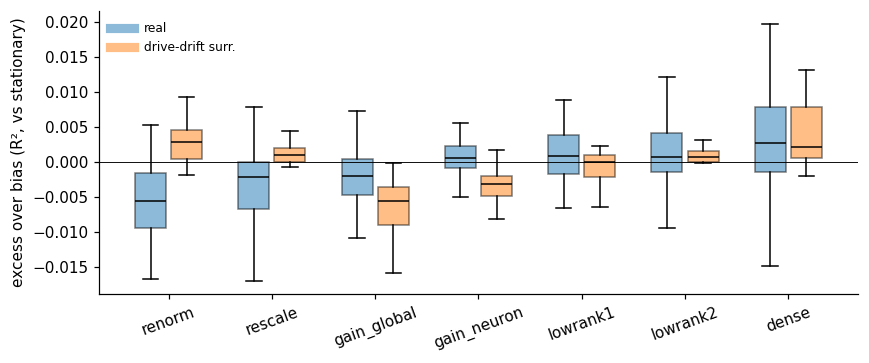

In [7]:
p_s = holm(np.nan_to_num([wtest([excess(o, "real", F) for o in det.values()]) for F in STRUCT], nan=1.0))
p_m = holm(np.nan_to_num([wtest([excess(o, "real", F) for o in det.values()]) for F in MEASF], nan=1.0))
for F, p in zip(STRUCT + MEASF, list(p_s) + list(p_m)):
    e = [excess(o, "real", F) for o in det.values()]
    print(f"  {F:12s} median excess {np.median(e) if e else float('nan'):+.4f}, positive in {sum(x > 0 for x in e)}/{len(e)}, Holm p = {p:.3g}")
FORMS = [F for F, p in zip(STRUCT, p_s) if p < 0.05]
STRUCTURE = bool(FORMS) and VALID
MEAS_FAMILY = bool(np.any(p_m < 0.05))
print("Registered rules -> STRUCTURE:", STRUCTURE, FORMS if FORMS else "", "| measurement family beats bias:", MEAS_FAMILY,
      "" if VALID else "(R1 INVALID: it flags structure in drive-only drift)")
if det:
    fig, ax = plt.subplots(figsize=(8, 3.4))
    fams = DK.FAMILIES[1:]
    for j, (lab, key, c) in enumerate([("real", "real", "tab:blue"), ("drive-drift surr.", "drive_drift", "tab:orange")]):
        src = det if key == "real" else det_bd
        data = [[excess(o, key, F) for o in src.values()] for F in fams]
        if any(len(d) for d in data):
            ax.boxplot(data, positions=np.arange(len(fams)) + (j - 0.5) * 0.35, widths=0.3, showfliers=False,
                       patch_artist=True, boxprops=dict(facecolor=c, alpha=0.5), medianprops=dict(color="k"))
            ax.plot([], [], c=c, lw=6, alpha=0.5, label=lab)
    ax.axhline(0, c="k", lw=0.6); ax.set_xticks(range(len(fams))); ax.set_xticklabels(fams, rotation=20)
    ax.set_ylabel("excess over bias (R², vs stationary)"); ax.legend(frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()

## 4 · Do the drives move together? (R2)

PC1 share of the drive changes (8 windows; 1 = all drives move along one direction):
  real 0.29 | stationary 0.23 | drive-drift surrogate 0.31 | Wilcoxon real > stationary p = 7.11e-15
Registered rule -> LOW_DIM: True


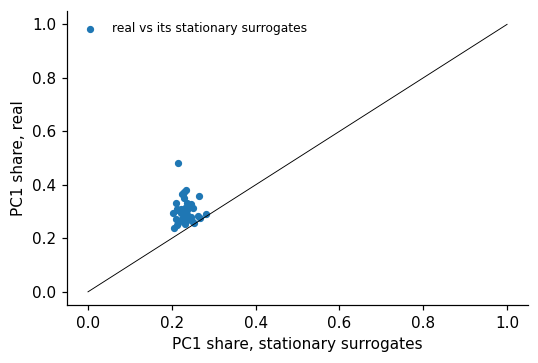

In [8]:
pc_real = np.array([o["real"]["pc1"] for o in det.values()])
pc_null = np.array([np.mean([n["pc1"] for n in o["null"]]) for o in det.values()])
pc_bd = np.array([o["drive_drift"]["pc1"] for o in det.values() if o["drive_drift"]])
pR2 = wtest(pc_real - pc_null)
LOW_DIM = bool(pR2 < 0.05)
print(f"PC1 share of the drive changes (8 windows; 1 = all drives move along one direction):")
print(f"  real {np.median(pc_real) if len(pc_real) else float('nan'):.2f} | stationary {np.median(pc_null) if len(pc_null) else float('nan'):.2f}"
      f" | drive-drift surrogate {np.median(pc_bd) if len(pc_bd) else float('nan'):.2f} | Wilcoxon real > stationary p = {pR2:.3g}")
print("Registered rule -> LOW_DIM:", LOW_DIM)
if len(pc_real):
    fig, ax = plt.subplots(figsize=(5, 3.4))
    ax.scatter(pc_null, pc_real, s=14, label="real vs its stationary surrogates")
    ax.plot([0, 1], [0, 1], "k-", lw=0.6); ax.set_xlabel("PC1 share, stationary surrogates"); ax.set_ylabel("PC1 share, real")
    ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

## 5 · Is it the microscope? (R3)

The unnormalised traces fade over a recording when the indicator bleaches. If the drift were a measurement artefact, recordings that fade more should drift more.

raw signal, last / first window (median over recordings): amplitude 0.88, mean 1.03
Spearman(drift gap, amplitude ratio) = +0.02 (Holm p 1) | (gap, mean ratio) = +0.17 (Holm p 1)


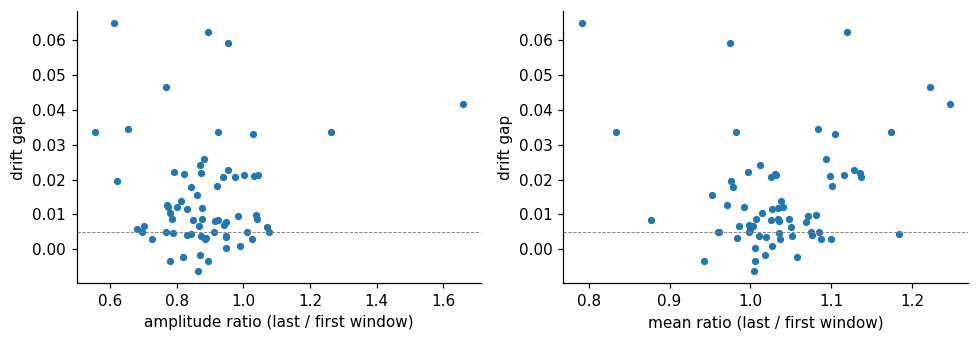

Registered rule -> MEAS_TREND: False


In [9]:
tr = [(o["real"]["gap"], o["trend"]["sd_ratio"], o["trend"]["mean_ratio"]) for o in ok.values() if o.get("trend")]
if len(tr) >= 6:
    g, sdr, mr = map(np.array, zip(*tr))
    r_sd = spearmanr(g, sdr, alternative="less"); r_m = spearmanr(g, mr, alternative="less")
    p3 = holm(np.array([r_sd.pvalue, r_m.pvalue]))
    MEAS_TREND = bool(np.any(p3 < 0.05))
    print(f"raw signal, last / first window (median over recordings): amplitude {np.median(sdr):.2f}, mean {np.median(mr):.2f}")
    print(f"Spearman(drift gap, amplitude ratio) = {r_sd.statistic:+.2f} (Holm p {p3[0]:.3g}) | (gap, mean ratio) = {r_m.statistic:+.2f} (Holm p {p3[1]:.3g})")
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
    for a, x, lab in [(ax[0], sdr, "amplitude ratio (last / first window)"), (ax[1], mr, "mean ratio (last / first window)")]:
        a.scatter(x, g, s=14); a.axhline(GAP_FLOOR, c="0.5", lw=0.6, ls="--"); a.set_xlabel(lab); a.set_ylabel("drift gap")
    plt.tight_layout(); plt.show()
else:
    MEAS_TREND = False; p3 = [float("nan")] * 2; print("raw traces not available in enough recordings")
print("Registered rule -> MEAS_TREND:", MEAS_TREND)

In [10]:
out = {"n": len(ok), "detected": {"real": len(det), "drive_drift": len(det_bd), "meas_drift": len(det_ms)},
       "R1": {"valid": VALID, "p_drive_drift": dict(zip(STRUCT, map(float, p_bd))), "p": dict(zip(STRUCT, map(float, p_s))),
              "forms": FORMS, "structure": STRUCTURE},
       "R1m": {"p": dict(zip(MEASF, map(float, p_m))), "measurement_family": MEAS_FAMILY},
       "R2": {"pc1_real": float(np.median(pc_real)) if len(pc_real) else None, "pc1_null": float(np.median(pc_null)) if len(pc_null) else None,
              "p": pR2, "low_dim": LOW_DIM},
       "R3": {"p": [float(x) for x in p3], "meas_trend": MEAS_TREND},
       "per_recording": rec}
json.dump(out, open(os.path.join(RESULTS, f"E3c_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E3c_result{TAG}.json")

saved E3c_result_laptop.json


## Results (laptop mode, 68 recordings, executed on the M1)

Drift was detected in **47/68** real recordings. The surrogates with planted drift were detected less often: 33/68 with drifting drives and 17/68 with drifting measurement. The real median gap is +0.0179, about twice the drive-drift surrogates' +0.0091.

**Family profile** (median advantage over `bias`, R²):

| | renorm | rescale | gain_global | gain_neuron | lowrank1 | lowrank2 | dense | PC1 |
|---|---|---|---|---|---|---|---|---|
| stationary | −0.0006 | −0.0007 | +0.0041 | +0.0009 | −0.0005 | −0.0006 | +0.0004 | 0.23 |
| drive drift | −0.0018 | −0.0011 | +0.0001 | −0.0004 | −0.0002 | +0.0004 | **+0.0043** | **0.31** |
| measurement drift | −0.0014 | −0.0015 | −0.0003 | −0.0001 | −0.0000 | −0.0002 | +0.0020 | 0.25 |
| **real** | −0.0054 | −0.0036 | +0.0020 | +0.0023 | +0.0004 | +0.0002 | **+0.0037** | **0.29** |

**R1 · structure: not established (the registered test is invalid).**
* On real data, only `dense` passes: median excess +0.0026, positive in 32/47 recordings, Holm p = 0.004.
* But the validity check fails. `dense` is flagged just as strongly on the drive-drift surrogates (Holm p ≈ 0), whose drift is in the drives only.
* A rich, regularised update gains about +0.004 from **any** drift, so its gain on real data is not evidence that couplings change.
* A follow-up check on one recording showed that this gain does not come from the self-couplings alone. The exact mechanism is not needed for the conclusion.
* Gains and low-rank changes add nothing beyond chance (Holm p ≥ 0.2).

**R1m · measurement families: no.**
* Correcting the traces' mean or scale is *worse* than refitting drives in real data: median excess −0.0056 (`renorm`) and −0.0022 (`rescale`), positive in only 11–12 of 47 recordings.

**R2 · low-dimensional drives: passes as registered, but fails its control.**
* Real PC1 share is 0.29 vs 0.23 for stationary surrogates (Wilcoxon p = 7×10⁻¹⁵).
* However, the drive-drift surrogates, whose drives drift *independently* in every neuron, reach 0.31.
* The statistic rises with any slow drift: a random walk's variance across 8 windows concentrates on one temporal mode, whatever the neurons do. The registered null (stationary) was the wrong comparison.
* Against the right null, the real drift is **no more low-dimensional than independent per-neuron drift**. Notebook 13 tests this paired against the drive-drift surrogates.

**R3 · measurement trend: no.**
* The raw signal changes little over a recording: last/first-window amplitude 0.88, mean 1.03.
* The drift gap does not grow with fading. The correlations even have the wrong sign: Spearman +0.02 with amplitude, +0.17 with mean; Holm p = 1.

**Outcome: the last row of the table below.** By every measure here, the real drift has the profile of the drive-drift surrogate:
* slow changes of each neuron's drive;
* no detectable gain, low-rank or coupling structure;
* not shared across neurons beyond what independent drift produces;
* not the microscope.

It is about twice as large as the planted drift. Notebook 13 (E3d) asks the last question imaging can answer about such drift: **do the drives wander, or do they return to set points (homeostasis)?**

## 6 · Reading the result

| outcome | reading for C3 | next |
|---|---|---|
| MEAS_TREND or MEAS_FAMILY | at least part of the drift is the microscope; Notebook 10's verdicts need a measurement correction before they are read as biology | re-run E3 on traces corrected for the fitted fading |
| LOW_DIM, no STRUCTURE | the drives of all neurons move along one slow direction: **one hidden slow variable**, not driven by recorded activity (Notebook 10 ruled that out) and not behavior (E3b). Candidates are a neuromodulator, unrecorded neurons, or internal state. A fixed program plus one unobserved slow input: the computer metaphor survives, with a hidden input | E3d: a latent-input meta-program, with d free slow inputs inferred from the data (a state-space model) |
| STRUCTURE = gain | the program's gains change: neuromodulatory gain control | E3d with a gain-modulating latent |
| STRUCTURE = lowrank / dense | the couplings themselves change. This is the strongest support yet for Brette's "the hardware is the program" | weight-modulating meta-program; look for the modes in identified (NeuroPAL) recordings |
| **none of these ← observed** (R1 invalid, R2 fails its control) | each neuron's drive drifts independently: drift without structure, which is equally consistent with independent slow changes in each neuron and with unrecorded inputs | the limit of what imaging alone can decide about the *form*; what remains is the drift's *time structure* (**E3d, Notebook 13: wander or return?**), then perturbation (E4) |

**Limits.**
* Everything is connectome-free (the baseline recordings have no identities). A rank-1 change of all-to-all couplings is not the same as a change of identified synapses.
* Each family is re-estimated from about 100 frames (half a window), so rich families are heavily regularised. "No structure" means *none detectable at this data size*.
* The measurement surrogate shows that additive measurement drift cannot be told from drive drift through the dynamics. R3 is therefore the only measurement test, and it is correlational.